# Image Classification with Convolution Neural Network

In [1]:
import os
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError
from tensorflow.keras.layers import BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix

I0000 00:00:1777392150.808836   16222 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
train_dir = "Dataset/train"
test_dir = "Dataset/test"
val_dir = "Dataset/val"

In [3]:
print(tf.config.list_physical_devices('GPU'))
# Expected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
print(tf.test.gpu_device_name())

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
/device:GPU:0


I0000 00:00:1777392163.728536   16222 gpu_device.cc:2043] Created device /device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [4]:
# Allow memory growth (allocates only what's needed)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

# Confirm GPU
print("GPU available:", len(gpus) > 0)

GPU available: True


In [5]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# Data Understanding, Analysis, Visualization and Cleaning

In [6]:
# Get class names (subdirectories)
def get_class_names(directory):
  class_names = sorted(os.listdir(directory))
  if not class_names:
    print("No class directories found in the train folder!")
  else:
    print(f"Found {len(class_names)} classes: {class_names}")

In [7]:
def check_corrupt_images(directory):
  corrupted_images = [] # List to store corrupted images path
  # Loop through each class folder and check for corrupted images
  class_names = sorted(os.listdir(directory))
  for class_name in class_names:
    class_path = os.path.join(directory, class_name)
    if os.path.isdir(class_path): # Ensure it’s a valid directory
      images = os.listdir(class_path)
      for img_name in images:
        img_path = os.path.join(class_path, img_name)
        try:
          with Image.open(img_path) as img:
            img.verify() # Verify image integrity
        except (IOError, UnidentifiedImageError):
          corrupted_images.append(img_path)
  # Print results
  if corrupted_images:
    print("\nCorrupted Images Found in ",directory)
    for img in corrupted_images:
      print(img)
  else:
    print("\nNo corrupted images found in ", directory)

In [8]:
print("For train directory")
get_class_names(train_dir)
check_corrupt_images(train_dir)
print("\nFor test directory")
get_class_names(test_dir)
check_corrupt_images(test_dir)
print("\nFor val directory")
get_class_names(val_dir)
check_corrupt_images(val_dir)

For train directory
Found 31 classes: ['Bangus', 'Big Head Carp', 'Black Spotted Barb', 'Catfish', 'Climbing Perch', 'Fourfinger Threadfin', 'Freshwater Eel', 'Glass Perchlet', 'Goby', 'Gold Fish', 'Gourami', 'Grass Carp', 'Green Spotted Puffer', 'Indian Carp', 'Indo-Pacific Tarpon', 'Jaguar Gapote', 'Janitor Fish', 'Knifefish', 'Long-Snouted Pipefish', 'Mosquito Fish', 'Mudfish', 'Mullet', 'Pangasius', 'Perch', 'Scat Fish', 'Silver Barb', 'Silver Carp', 'Silver Perch', 'Snakehead', 'Tenpounder', 'Tilapia']

No corrupted images found in  Dataset/train

For test directory
Found 31 classes: ['Bangus', 'Big Head Carp', 'Black Spotted Barb', 'Catfish', 'Climbing Perch', 'Fourfinger Threadfin', 'Freshwater Eel', 'Glass Perchlet', 'Goby', 'Gold Fish', 'Gourami', 'Grass Carp', 'Green Spotted Puffer', 'Indian Carp', 'Indo-Pacific Tarpon', 'Jaguar Gapote', 'Janitor Fish', 'Knifefish', 'Long-Snouted Pipefish', 'Mosquito Fish', 'Mudfish', 'Mullet', 'Pangasius', 'Perch', 'Scat Fish', 'Silver Barb'

In [9]:
def count_class(directory):
  class_names = sorted(os.listdir(directory))
  class_counts = {}
  for class_name in class_names:
    class_path = os.path.join(directory, class_name)
    if os.path.isdir(class_path):
      images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg'
      , '.jpeg'))]
      class_counts[class_name] = len(images) # Count images in each class
  # Print Class Balance
  print("\nClass Distribution:")
  print("=" * 45)
  print(f"{'Class Name':<25}{'Valid Image Count':>15}")
  print("=" * 45)
  for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
  print("=" * 45)

In [10]:
print("Train directory")
count_class(train_dir)
print("\nTest directory")
count_class(test_dir)
print("\nVal directory")
count_class(val_dir)

Train directory

Class Distribution:
Class Name               Valid Image Count
Bangus                               171
Big Head Carp                        201
Black Spotted Barb                   200
Catfish                              314
Climbing Perch                       152
Fourfinger Threadfin                 191
Freshwater Eel                       271
Glass Perchlet                       397
Goby                                 607
Gold Fish                            206
Gourami                              311
Grass Carp                          1212
Green Spotted Puffer                 110
Indian Carp                          262
Indo-Pacific Tarpon                  186
Jaguar Gapote                        229
Janitor Fish                         286
Knifefish                            319
Long-Snouted Pipefish                256
Mosquito Fish                        254
Mudfish                              189
Mullet                               174
Pangasius         

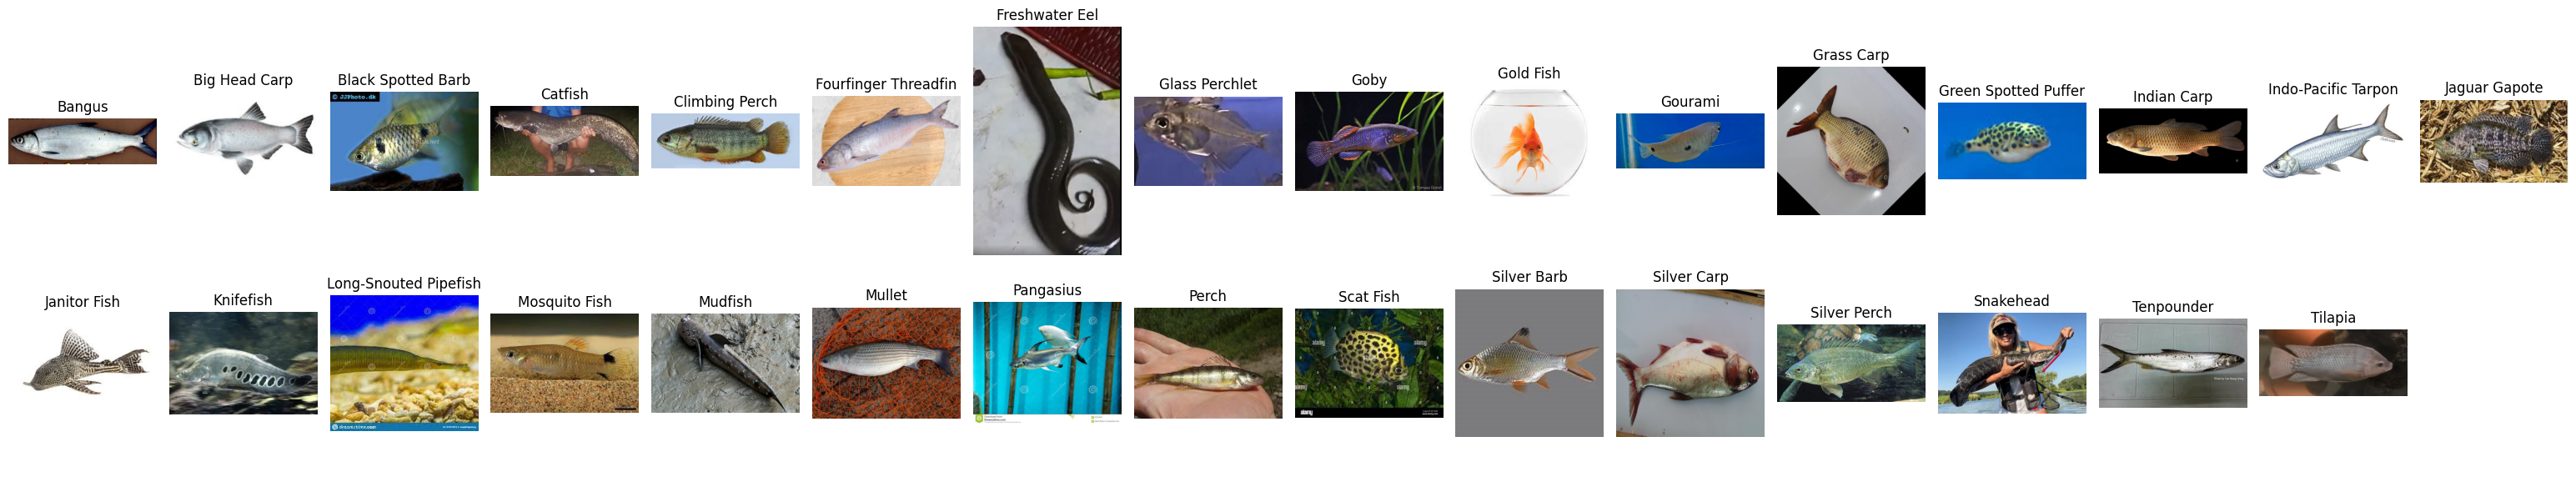

In [11]:
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
class_names = sorted(os.listdir(train_dir))
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg'
    , '.jpeg'))]
    if images: # Ensure the class folder is not empty
      selected_img = os.path.join(class_path, random.choice(images))
      selected_images.append(selected_img)
      selected_labels.append(class_name)
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(31, 6))
for i, ax in enumerate(axes.flat):
  if i < num_classes:
    img = mpimg.imread(selected_images[i])
    ax.imshow(img)
    ax.set_title(selected_labels[i])
    ax.axis("off")
  else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

# Task 2: Loading and Preprocessing Image Data

In [12]:
img_height = 224
img_width = 224
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=True,
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=False,
    seed=123
)

num_classes = len(train_ds.class_names)
class_names = train_ds.class_names

Found 8809 files belonging to 31 classes.


I0000 00:00:1777392798.790453   16222 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 2751 files belonging to 31 classes.


In [13]:
model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),         # Only normalization here

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/50


I0000 00:00:1777392813.464820   16474 service.cc:153] XLA service 0x7b2ca0036f70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777392813.464910   16474 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777392813.730159   16474 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777392814.631961   16474 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1777392814.695987   16474 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2422__.55
I0000 00:00:1777392820.905045   16474 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

  1/276 ━━━━━━━━━━━━━━━━━━━━ 2:50:20 37s/step - accuracy: 0.0000e+00 - loss: 3.4459

I0000 00:00:1777392847.484037   16474 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


274/276 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.1465 - loss: 3.2407

I0000 00:00:1777392867.593949   16473 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2422__.55


276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.1468 - loss: 3.2395

I0000 00:00:1777392890.947759   16471 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1777392898.596852   16471 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


276/276 ━━━━━━━━━━━━━━━━━━━━ 90s 194ms/step - accuracy: 0.1876 - loss: 3.0755 - val_accuracy: 0.2457 - val_loss: 2.7333
Epoch 2/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.3054 - loss: 2.5404 - val_accuracy: 0.3980 - val_loss: 2.2130
Epoch 3/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.4198 - loss: 2.0961 - val_accuracy: 0.5267 - val_loss: 1.7747
Epoch 4/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.5329 - loss: 1.7010 - val_accuracy: 0.5678 - val_loss: 1.5223
Epoch 5/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.6200 - loss: 1.3843 - val_accuracy: 0.6808 - val_loss: 1.1782
Epoch 6/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - accuracy: 0.6962 - loss: 1.0989 - val_accuracy: 0.7521 - val_loss: 0.9440
Epoch 7/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 25s 89ms/step - accuracy: 0.7680 - loss: 0.8476 - val_accuracy: 0.7859 - val_loss: 0.8027
Epoch 8/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 24s 86ms/step - accuracy: 0.8277 - loss: 0.6486 - val_accura

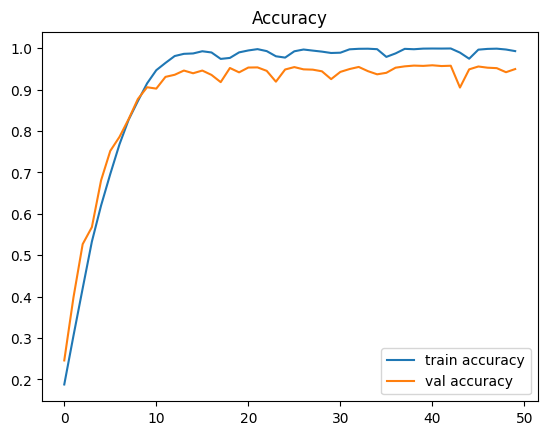

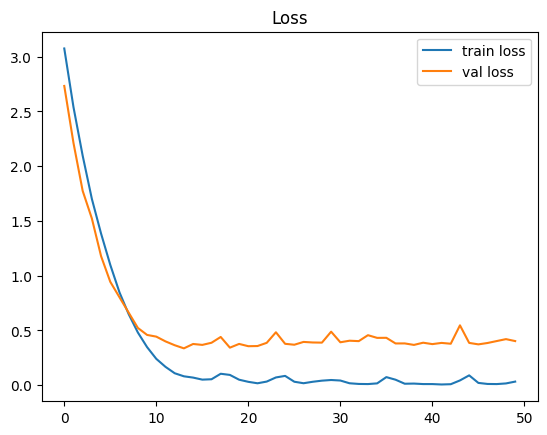

In [16]:
# Accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

In [17]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (x/255.0, y))

Found 1761 files belonging to 31 classes.


In [18]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.0290 - loss: 7.9464
Test Loss: 7.9464
Test Accuracy: 0.0290
